# Import Important Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# SARIMA model (seasonal ARIMA)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMAX (SARIMA with exogenous variables) 
# → uses the same SARIMAX class as above
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [2]:
df = pd.read_csv('HHS_Unaccompanied_Alien_children_Program.csv')

In [3]:
rows_with_NaN = df.isna().any(axis = 1).mean()*100
print("Percentage of NaN values {} %".format(round(rows_with_NaN)))

Percentage of NaN values 38 %


In [4]:
mask = df.isna().any(axis=1)
missing_indices = df.index[mask]
print(missing_indices)

RangeIndex(start=720, stop=1170, step=1)


In [5]:
def fix_missing_dates(df, date_col='Date', method='time'):
    
    df[date_col] = pd.to_datetime(df[date_col])   #Ensure datetime index
    df = df.set_index(date_col)

   
    df = df.groupby(df.index).mean()       #  Handle duplicate dates (aggregate by mean)


    full_range = pd.date_range(df.index.min(), df.index.max(), freq='D')   #  Build full date range
    df = df.reindex(full_range)

    #  Interpolate numeric columns only
    
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].interpolate(method=method)

    # 5. Fill non-numeric columns separately
    non_numeric_cols = df.select_dtypes(exclude=['number']).columns
    df[non_numeric_cols] = df[non_numeric_cols].ffill().bfill()

    # 6. Drop trailing all-NaN rows
    df = df.loc[:df.dropna(how='all').index.max()]

    return df




In [6]:
df['Children in HHS Care'] = (
    pd.to_numeric(df['Children in HHS Care'].astype(str).str.replace(',', ''), errors='coerce')
)


In [7]:
df = fix_missing_dates(df, date_col='Date', method='time')
print(df.head(15))

            Children apprehended and placed in CBP custody*  \
2023-01-12                                            33.00   
2023-01-13                                            32.90   
2023-01-14                                            32.80   
2023-01-15                                            32.70   
2023-01-16                                            32.60   
2023-01-17                                            32.50   
2023-01-18                                            32.40   
2023-01-19                                            32.30   
2023-01-20                                            32.20   
2023-01-21                                            32.10   
2023-01-22                                            32.00   
2023-01-23                                            32.00   
2023-01-24                                            47.00   
2023-01-25                                            20.00   
2023-01-26                                            2

In [8]:
df['Children in HHS Care'] = df['Children in HHS Care'].interpolate(method='linear')

In [9]:
duplicates = df.index.duplicated()
print(duplicates)

[False False False ... False False False]


In [10]:
df.isnull().sum()

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

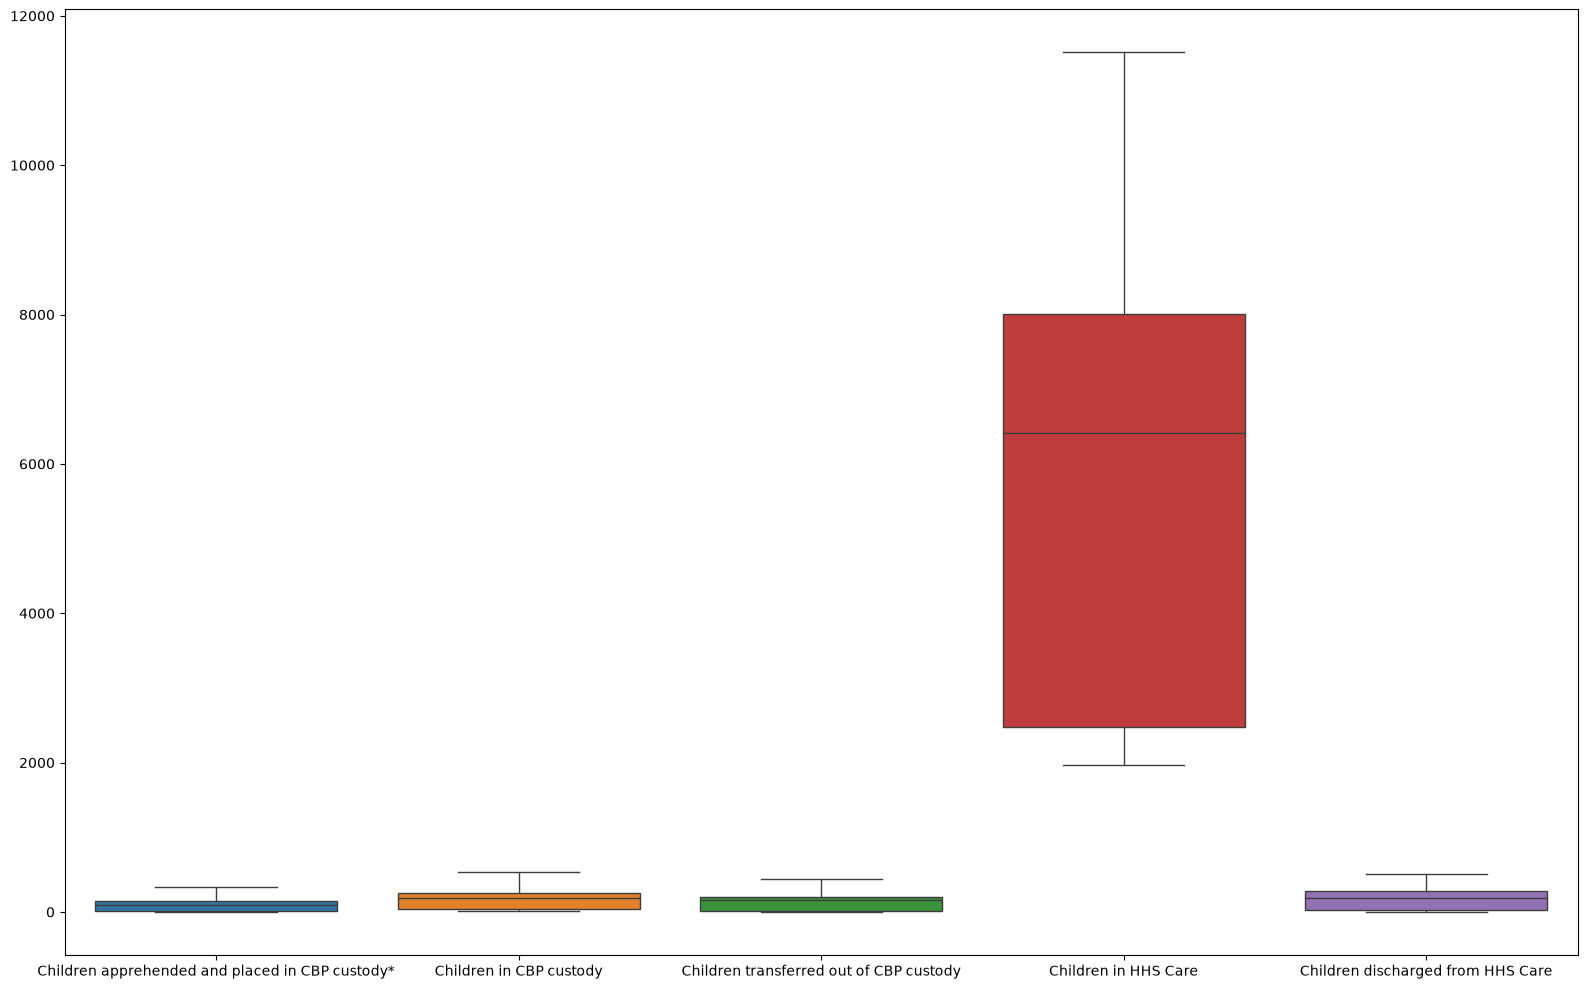

In [11]:
plt.figure(figsize=(16,10))
sns.boxplot(df[['Children apprehended and placed in CBP custody*','Children in CBP custody',
            'Children transferred out of CBP custody','Children in HHS Care',
            'Children discharged from HHS Care']])

plt.tight_layout()
plt.show()

In [12]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]
outliers = {}
for col in df.columns:
    outliers[col] = detect_outliers_iqr(df[col])
for col, vals in outliers.items():
    print(f"{col} -> {len(vals)} outliers")
    if not vals.empty:
        print(vals.values)


Children apprehended and placed in CBP custody* -> 0 outliers
Children in CBP custody -> 0 outliers
Children transferred out of CBP custody -> 0 outliers
Children in HHS Care -> 0 outliers
Children discharged from HHS Care -> 0 outliers


In [13]:
cols_to_check = ['Children apprehended and placed in CBP custody*',
                'Children transferred out of CBP custody','Children discharged from HHS Care']
zero_counts = (df[cols_to_check] == 0).sum()

print(zero_counts)

Children apprehended and placed in CBP custody*    2
Children transferred out of CBP custody            3
Children discharged from HHS Care                  1
dtype: int64


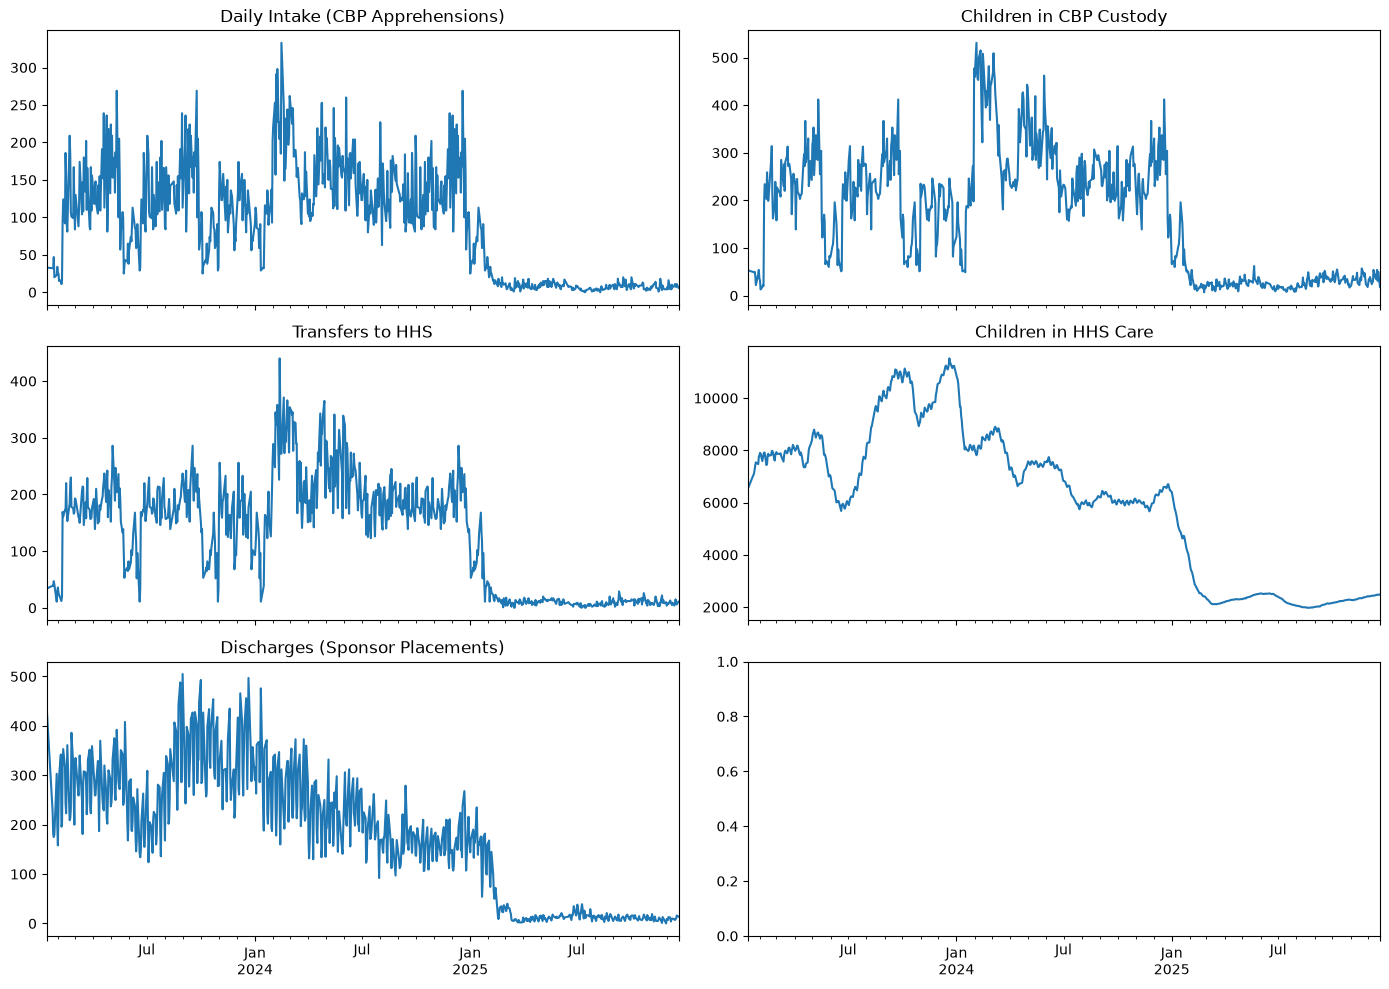

In [14]:

fig, axes = plt.subplots(3, 2, figsize=(14,10), sharex=True)

df['Children apprehended and placed in CBP custody*'].plot(ax=axes[0,0], title="Daily Intake (CBP Apprehensions)")
df['Children in CBP custody'].plot(ax=axes[0,1], title="Children in CBP Custody")
df['Children transferred out of CBP custody'].plot(ax=axes[1,0], title="Transfers to HHS")
df['Children in HHS Care'].plot(ax=axes[1,1], title="Children in HHS Care")
df['Children discharged from HHS Care'].plot(ax=axes[2,0], title="Discharges (Sponsor Placements)")

plt.tight_layout()
plt.show()


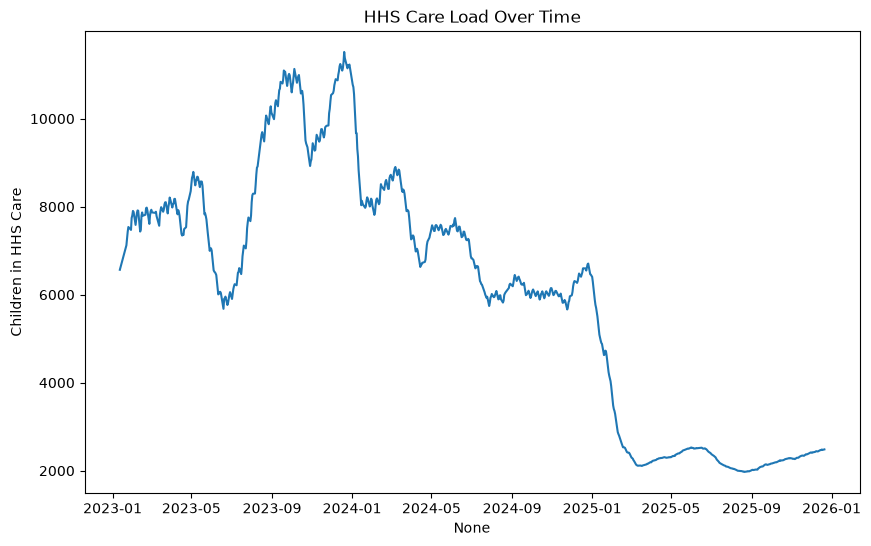

In [15]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=df.index, y=df['Children in HHS Care'])
plt.title('HHS Care Load Over Time')
plt.show()

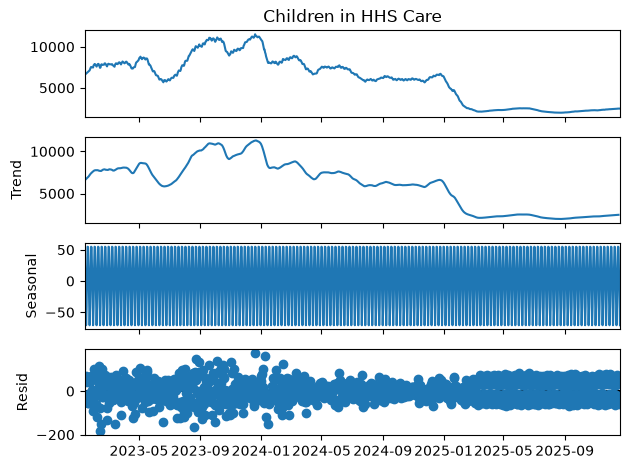

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Children in HHS Care'], model='additive',period=7)   # Seasonal Decomposition
result.plot()
plt.show()

In [17]:
df['dow'] = df.index.dayofweek  # Capture weekly seasonality
df['month'] = df.index.month    #Monthly seasonality
df['lag1'] = df['Children in HHS Care'].shift(1)     # value yesterday
df['lag7'] = df['Children in HHS Care'].shift(7)
df['rolling_mean_7'] = df['Children in HHS Care'].rolling(7).mean()   # Smooths noise
df['rolling_var_7'] = df['Children in HHS Care'].rolling(7).var()     # Measures Variability in the past week
df['rolling_std_7'] = df['Children in HHS Care'].rolling(7).std()    # direct measure of volatility
df['net_pressure'] = df['Children transferred out of CBP custody'] - df['Children discharged from HHS Care']  

In [18]:
df["policy_change"] = (df.index >= "2025-01-01").astype(int)

In [19]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [20]:
test

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,dow,month,lag1,lag7,rolling_mean_7,rolling_var_7,rolling_std_7,net_pressure,policy_change
2025-05-21,14.000000,62.000000,13.000000,2467.0,18.000000,2,5,2462.0,2394.000000,2440.000000,499.333333,22.345768,-5.000000,1
2025-05-22,18.000000,36.000000,17.000000,2473.0,15.000000,3,5,2467.0,2410.000000,2449.000000,436.333333,20.888593,2.000000,1
2025-05-23,15.600000,33.600000,15.000000,2479.2,14.200000,4,5,2473.0,2419.000000,2457.600000,352.053333,18.763084,0.800000,1
2025-05-24,13.200000,31.200000,13.000000,2485.4,13.400000,5,5,2479.2,2428.000000,2465.800000,256.386666,16.012079,-0.400000,1
2025-05-25,10.800000,28.800000,11.000000,2491.6,12.600000,6,5,2485.4,2437.000000,2473.600000,158.106666,12.574047,-1.600000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-17,7.000000,31.000000,11.000000,2481.0,10.000000,2,12,2468.0,2439.000000,2459.571429,231.989418,15.231199,1.000000,1
2025-12-18,11.000000,50.000000,6.000000,2472.0,16.000000,3,12,2481.0,2437.000000,2464.571429,143.656084,11.985662,-10.000000,1
2025-12-19,9.333333,39.333333,7.666667,2476.0,15.333333,4,12,2472.0,2445.333333,2468.952381,81.349206,9.019379,-7.666667,1
2025-12-20,7.666667,28.666667,9.333333,2480.0,14.666667,5,12,2476.0,2453.666667,2472.714286,46.238095,6.799860,-5.333333,1


In [21]:
series = df['Children in HHS Care']
#steps = 30

In [32]:
def naive_forecast(series, steps):
    return np.repeat(series.iloc[-1], steps)

def moving_average_forecost(series, steps, window=7):
    return np.repeat(series.iloc[-window:].mean(), steps)


In [36]:
df.columns

Index(['Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care', 'dow',
       'month', 'lag1', 'lag7', 'rolling_mean_7', 'rolling_var_7',
       'rolling_std_7', 'net_pressure', 'policy_change'],
      dtype='str')

In [39]:
exog_train = train[["Children apprehended and placed in CBP custody*","Children in CBP custody",
                    "Children transferred out of CBP custody","Children discharged from HHS Care",
                   "dow","month","lag1","lag7","rolling_mean_7","rolling_var_7",
                    "rolling_std_7","net_pressure","policy_change"]]
exog_test  = test[["Children apprehended and placed in CBP custody*","Children in CBP custody",
                    "Children transferred out of CBP custody","Children discharged from HHS Care",
                   "dow","month","lag1","lag7","rolling_mean_7","rolling_var_7",
                    "rolling_std_7","net_pressure","policy_change"]]
# Replace inf with NaN, then fill
exog_train = exog_train.replace([np.inf, -np.inf], np.nan).bfill().ffill()
exog_test  = exog_test.replace([np.inf, -np.inf], np.nan).bfill().ffill()



sarimax = SARIMAX(train["Children in HHS Care"], exog=exog_train,
                  order=(2,1,2), seasonal_order=(1,1,1,7)).fit(disp=False, method ='powell', maxiter=200)
sarimax_pred = sarimax.forecast(len(test), exog=exog_test)


In [48]:
from sklearn.linear_model import LinearRegression

X_train, y_train = exog_train, train["Children in HHS Care"]
X_test, y_test = exog_test, test["Children in HHS Care"]

lr = LinearRegression().fit(X_train, y_train)
forecast_lr = lr.predict(X_test)


In [49]:
naive_pred = naive_forecast(series, steps=len(y_test))
ma_pred = moving_average_forecost(series, steps=len(y_test), window=7)

In [50]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ARIMA
arima = ARIMA(y_train, order=(1,0,1)).fit()
arima_pred = arima.forecast(len(y_test))

# SARIMA
sarima = SARIMAX(y_train, order=(1,0,1),
                 seasonal_order=(1,1,1,7)).fit(disp=False, method ='powell', maxiter=200)
sarima_pred = sarima.forecast(len(y_test))


In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=900,       # number of boosting rounds
    learning_rate=0.1,     # shrinkage step
    max_depth=6,            # tree depth
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # feature sampling
    random_state=42)
xgb.fit(X_train, y_train)
forecast_xgb = xgb.predict(X_test)


In [56]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(
    n_estimators=900,   # number of trees
    learning_rate=0.1, # shrinkage
    max_depth=8,        # tree depth
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

        


In [58]:
test.shape,ma_pred.shape,arima_pred.shape,sarima_pred.shape,test[-len(test):].shape,naive_pred.shape,forecast_lr.shape,y_test.shape

((215, 14), (215,), (215,), (215,), (215, 14), (215,), (215,), (215,))

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%, SMAPE: {smape:.2f}, R²: {r2:.3f}")

evaluate(y_test[-len(y_test):], naive_pred, "Naive Forecast")
evaluate(y_test[-len(y_test):], ma_pred, "Moving Average Forecast")
evaluate(y_test[-len(y_test):], arima_pred, "ARIMA")
evaluate(y_test[-len(y_test):], sarima_pred, "SARIMA")
evaluate(y_test, sarimax_pred, "SARIMAX")
evaluate(y_test[-len(test):], forecast_lr, "Linear Regression")
evaluate(y_test[-len(test):], forecast_xgb, "XGBoost")
evaluate(y_test[-len(test):], gb_pred, "GradientBoostingRegressor")


Naive Forecast → MAE: 234.18, RMSE: 288.91, MAPE: 11.04%, SMAPE: 10.16, R²: -1.605
Moving Average Forecast → MAE: 228.66, RMSE: 282.56, MAPE: 10.78%, SMAPE: 9.94, R²: -1.492
ARIMA → MAE: 542.04, RMSE: 603.78, MAPE: 24.83%, SMAPE: 21.48, R²: -10.376
SARIMA → MAE: 195.66, RMSE: 247.05, MAPE: 9.24%, SMAPE: 8.60, R²: -0.905
SARIMAX → MAE: 36.25, RMSE: 43.48, MAPE: 1.63%, SMAPE: 1.65, R²: 0.941
Linear Regression → MAE: 33.12, RMSE: 39.06, MAPE: 1.48%, SMAPE: 1.49, R²: 0.952
XGBoost → MAE: 40.40, RMSE: 60.71, MAPE: 1.91%, SMAPE: 1.87, R²: 0.885
GradientBoostingRegressor → MAE: 34.99, RMSE: 52.43, MAPE: 1.64%, SMAPE: 1.61, R²: 0.914


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert NumPy arrays to pandas Series with datetime index
forecast_lr = pd.Series(forecast_lr.flatten(), index=test.index)
forecast_xgb = pd.Series(forecast_xgb.flatten(), index=test.index)
gb_forecast = pd.Series(gb_pred.flatten(), index=test.index)

In [64]:
gb_forecast

Date
2025-05-21    2461.311313
2025-05-22    2462.474240
2025-05-23    2462.377061
2025-05-24    2461.278526
2025-05-25    2443.230612
                 ...     
2025-12-17    2457.796885
2025-12-18    2455.394219
2025-12-19    2455.870000
2025-12-20    2458.158746
2025-12-21    2441.846735
Length: 215, dtype: float64

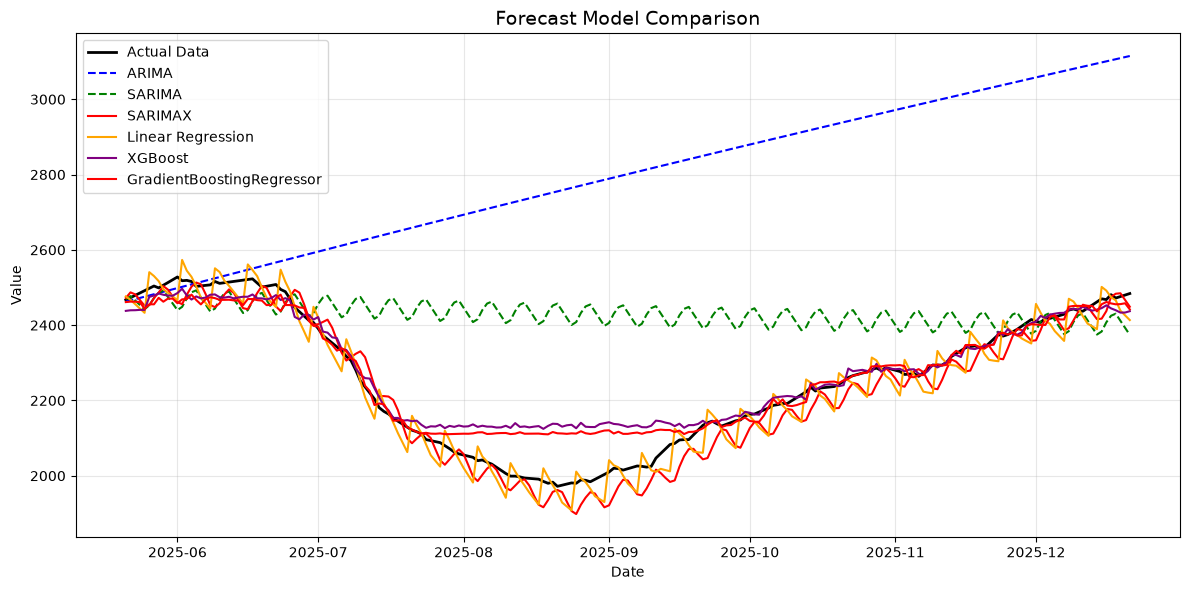

In [65]:
import matplotlib.pyplot as plt

# Example data (replace with your actual forecast arrays)
# Each forecast should be a pandas Series with a DateTime index

# Plot setup
plt.figure(figsize=(12,6))
plt.plot(test.index,test['Children in HHS Care'], label='Actual Data', color='black', linewidth=2)
plt.plot(arima_pred, label='ARIMA', color='blue', linestyle='--')
plt.plot(sarima_pred, label='SARIMA', color='green', linestyle='--')
plt.plot(sarimax_pred, label='SARIMAX', color='red')
plt.plot(forecast_lr, label='Linear Regression', color='orange')
plt.plot(forecast_xgb, label='XGBoost', color='purple')
plt.plot(gb_forecast, label='GradientBoostingRegressor', color='red')

# Labels and legend
plt.title('Forecast Model Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [72]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np

# Title
st.title("Forecasting Model Comparison Dashboard")

# Upload data
uploaded_file = st.file_uploader("HHS_Unaccompanied_Alien_children_Program.csv", type="csv")
if uploaded_file:
    df = pd.read_csv(uploaded_file, parse_dates=['date'], index_col='date')
    st.write("Data Preview:", df.head())

    target_col = st.selectbox("Select target column", df.columns)

    # Train/test split
    steps = st.slider("Forecast horizon (steps)", 5, 50, 10)
    train, test = df[:-steps], df[-steps:]

    # Train ARIMA
    arima_model = ARIMA(train[target_col], order=(1,1,1)).fit()
    arima_pred = arima_model.forecast(steps=steps)

    # Train XGBoost
    X = train.drop(target_col, axis=1, errors='ignore')
    y = train[target_col]
    xgb = XGBRegressor()
    xgb.fit(X, y)
    X_test = test.drop(target_col, axis=1, errors='ignore')
    xgb_pred = xgb.predict(X_test)

    # Evaluation
    mae_arima = mean_absolute_error(test[target_col], arima_pred)
    mae_xgb = mean_absolute_error(test[target_col], xgb_pred)

    def evaluate(y_true, y_pred, name):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mask = y_true != 0
        if mask.sum() > 0:
            mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        else:
            mape = np.nan
        smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
        r2 = r2_score(y_true, y_pred)
        return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape, "R²": r2}

# --- Streamlit UI ---
    st.title("📊 Forecast Model Evaluation Dashboard")
    available_models = [
    "Naive Forecast", "Moving Average Forecast", "ARIMA",
    "SARIMA", "SARIMAX", "Linear Regression",
    "XGBoost", "GradientBoostingRegressor"
]
    selected_models = st.sidebar.multiselect("Select Models to Evaluate", available_models, default=available_models)
    pred_map = {
    "Naive Forecast": naive_pred,
    "Moving Average Forecast": ma_pred,
    "ARIMA": arima_pred,
    "SARIMA": sarima_pred,
    "SARIMAX": sarimax_pred,
    "Linear Regression": forecast_lr,
    "XGBoost": forecast_xgb,
    "GradientBoostingRegressor": gb_pred
}

# Collect results
    results = []
    for model in selected_models:
        results.append(evaluate(y_test, pred_map[model], model))
    
    # Display results as table
    df_results = pd.DataFrame(results)
    st.dataframe(df_results.style.format({"MAE":"{:.2f}", "RMSE":"{:.2f}", "MAPE":"{:.2f}%", "SMAPE":"{:.2f}", "R²":"{:.3f}"}))
    
    # Optional: bar chart comparison
    st.bar_chart(df_results.set_index("Model")[["MAE","RMSE","MAPE","SMAPE"]])
    # Plot
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(test.index, test[target_col], label="Actual Data", color="black")
    ax.plot(test.index, arima_pred, label="ARIMA", linestyle="--", color="blue")
    ax.plot(test.index, xgb_pred, label="XGBoost", color="purple")
    ax.legend()
    st.pyplot(fig)


2026-07-21 13:24:57.657 
  command:

    streamlit run C:\Users\amar0\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


In [38]:
streamlit run C:\Users\amar0\anaconda3\Lib\site-packages\ipykernel_launcher.py


SyntaxError: invalid syntax (3320937190.py, line 1)